# 车靠边走，五根梁怎样重新分担？

先猜：120 kN的车停在桥中线右侧2.4 m时，最右梁会分到一半车重吗？

本页HTML展示已运行的Python结果，不会在浏览器里重新执行Python。下载.ipynb，在Jupyter打开，改参数后选择“重新启动内核并运行全部”。依赖：Python 3、numpy、matplotlib、ipykernel。

## 先把比较的对象说清楚
五根梁竖向刚度相同，横向连接理想化为刚杆。这里只算车辆的增量，不计恒载。R表示横向分到各梁的等效力，不是实际支座的总反力。

对应核心单元C04U05、C04U10和C02U01—03。原核心视频是四梁归一模型，本页是五梁、120 kN的独立算例；先对齐模型再比较数字。

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"font.sans-serif":["Microsoft YaHei","SimHei","DejaVu Sans"],
                     "axes.unicode_minus":False, "figure.dpi":120})
print("Python", sys.version.split()[0], "；NumPy", np.__version__)

Python 3.13.5 ；NumPy 2.2.6


## 改一个参数
先只改车位e。y是各梁离桥中线的距离；长度用m，力用kN。

In [2]:
#| label: parameters-transverse
P=120.0
y=np.array([-4.8,-2.4,0.0,2.4,4.8])
e=2.4
assert P>0 and np.isfinite(e)
print("各梁位置/m：", y, "；车位/m：",e)

各梁位置/m： [-4.8 -2.4  0.   2.4  4.8] ；车位/m： 2.4


## 平均分担，再平衡偏心力矩
刚杆的竖向位移沿宽度排成直线；等刚度使力也线性变化。对称位置满足$\sum y_i=0$，所以
$$R_i=\frac{P}{5}+\frac{P e y_i}{\sum_j y_j^2}.$$
第一项合计P，第二项合计零；第二项提供Pe的力矩。

In [3]:
def distribute(e,P=120.0):
    return P/len(y)+P*e*y/np.dot(y,y)
R=distribute(e,P)
print("R / kN =",np.round(R,6))
print("最右梁分担比例 =",round(R[-1]/P,6))
print("合力 / kN =",R.sum(),"；力矩 / kN·m =",R@y)
assert np.isclose(R.sum(),P) and np.isclose(R@y,P*e)

R / kN = [ 0. 12. 24. 36. 48.]
最右梁分担比例 = 0.4
合力 / kN = 120.0 ；力矩 / kN·m = 288.0


## 把两次摆法放在一起
蓝色是中心车位，橙色是当前车位。负柱子是车辆作用在这个双向传力模型中的负分量。

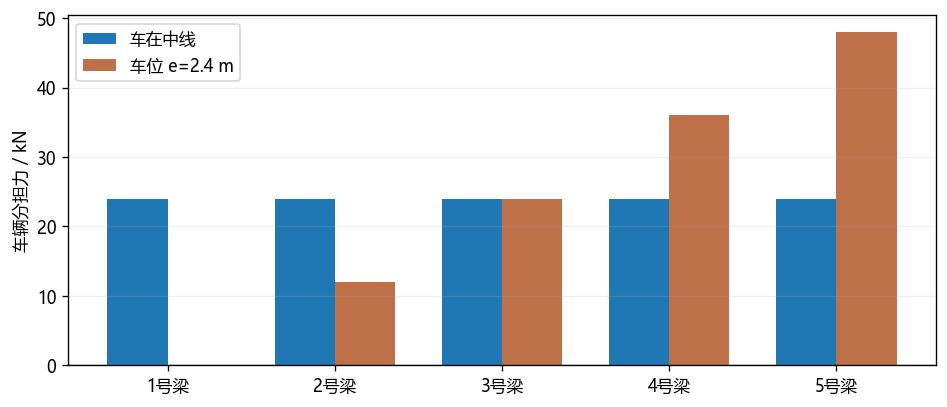

In [4]:
#| label: fig-transverse
fig,ax=plt.subplots(figsize=(8,3.5))
i=np.arange(5)
ax.bar(i-.18,distribute(0,P),.36,label="车在中线")
ax.bar(i+.18,R,.36,label=f"车位 e={e:g} m",color="#be7048")
ax.axhline(0,color="#455a64",lw=.8)
ax.set(xticks=i,xticklabels=[f"{j}号梁" for j in range(1,6)],ylabel="车辆分担力 / kN")
ax.legend();ax.grid(axis="y",alpha=.2);fig.tight_layout();plt.show()

## 算出负数，要直接删掉吗？
把e改为3.6 m，先用原模型算。再取**另一个模型**：刚性横梁放在五个等刚度、只能承压的弹簧上。它的开口接触状态需要重新求解。下面的a、b是取共同相对刚度为1后的归一量，不是实桥毫米位移。

In [5]:
def compression_only(e,P=120.0):
    for mask in range(1,1<<len(y)):
        active=np.array([bool(mask&(1<<i)) for i in range(len(y))])
        if active.sum()<2: continue
        ya=y[active]
        G=np.array([[len(ya),ya.sum()],[ya.sum(),ya@ya]],float)
        a,b=np.linalg.solve(G,[P,P*e])
        u=a+b*y
        if np.all(u[active]>=-1e-9) and np.all(u[~active]<=1e-9):
            return np.where(active,np.maximum(u,0),0),u,active
    raise ValueError("当前荷载没有本页可稳定求解的接触组")
signed=distribute(3.6)
clipped=np.maximum(signed,0)
contact,u,active=compression_only(3.6)
for name,r in [("原双向模型",signed),("直接删负数",clipped),("另一个单向模型",contact)]:
    print(name,":",np.round(r,4),"；合力",round(r.sum(),4),"；力矩",round(r@y,4))
assert np.allclose(signed,[-12,6,24,42,60])
assert np.allclose(contact,[0,0,10,40,70])
assert np.isclose(contact.sum(),120) and np.isclose(contact@y,432)
assert np.all(u[~active]<=1e-9)

原双向模型 : [-12.   6.  24.  42.  60.] ；合力 120.0 ；力矩 432.0
直接删负数 : [ 0.  6. 24. 42. 60.] ；合力 132.0 ；力矩 374.4
另一个单向模型 : [ 0.  0. 10. 40. 70.] ；合力 120.0 ；力矩 432.0


## 与偏心受压，哪一步相像？
在线弹性、未开裂、平截面假设内，压应力可写为$\sigma=N/A+My/I$。矩形截面沿偏心方向高度h，有$\sigma_{\min}=N/A(1-6e/h)$。平均部分加线性增减，是共同的思路。
但一个结果是连续截面的应力，另一个是离散梁分担力；$h/6$不是钢筋混凝土大、小偏心受压的分界。

In [6]:
#| label: checks-transverse
mean_stress=10.0 # MPa
eccentric_ratio=1/6
sigma_min=mean_stress*(1-6*eccentric_ratio)
print("e/h=1/6时，未开裂矩形截面的最小压应力 / MPa =",sigma_min)
assert np.isclose(sigma_min,0)
for pos in [-3.6,0,2.4,3.6]:
    r=distribute(pos)
    assert np.isclose(r.sum(),120) and np.isclose(r@y,120*pos)
print("自检通过：合力、合矩、两个已知工况和截面核心基准。")

e/h=1/6时，未开裂矩形截面的最小压应力 / MPa = 0.0
自检通过：合力、合矩、两个已知工况和截面核心基准。


## 合上结果，自己解释
1. 车重翻倍，R和R/P分别怎样变？
2. 只看总力对了，能否确认分配正确？
3. 真实支座出现脱空，需要把哪些恒载与活载、连接条件一起检查？

**本次默认结果：**最右梁48 kN，占40%。3.6 m时原模型左梁−12 kN，不能据此断言计入恒载后的实桥支座已经脱空。